# Real-World Data Experiments

In [1]:
# Optional: in case the imports for the local folders/files fail
import os

if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("../")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_USD_JPY as USDJPY
from dukascopy_python.instruments import INSTRUMENT_IDX_AMERICA_E_SANDP_500 as SP500
from data import data_utils
from analysis import models, plots

In [3]:
# Data directories
FOMC_DATA_DIR = Path(rf"data/fomc_tick_data")
CONTROL_DATA_DIR = Path(rf"data/control_group_tick_data")

In [4]:
# Asset constants
LEADER = SP500
TARGET = USDJPY

## Data Loading

In [5]:
fomc_data = data_utils.load_datasets_into_dict(FOMC_DATA_DIR)
control_group_data = data_utils.load_datasets_into_dict(CONTROL_DATA_DIR)

In [6]:
# Extracting returns
def extract_return_series(event_df, leader_col, target_col):
    """Outputs a tuple of event_df's log returns for leader and target"""
    leader_returns = np.log(event_df[leader_col]).diff()
    target_returns = np.log(event_df[target_col]).diff()
    aligned = pd.concat([leader_returns, target_returns], axis=1).dropna()
    return aligned.iloc[:, 0].values, aligned.iloc[:, 1].values


# Returns for the forward direction (equities leads FX)
fomc_data_returns_forward = [
    extract_return_series(df, LEADER, TARGET) for df in fomc_data.values()
]
control_group_data_returns_forward = [
    extract_return_series(df, LEADER, TARGET) for df in control_group_data.values()
]

# Returns for the backward direction (FX leads equities)
fomc_data_returns_backward = [
    extract_return_series(df, TARGET, LEADER) for df in fomc_data.values()
]
control_group_data_returns_backward = [
    extract_return_series(df, TARGET, LEADER) for df in control_group_data.values()
]

## Model 1: Lagged Crossed-Correlations

### No need to run this one twice (for each direction of the relationship) it's embedded in the plot

In [7]:
long_table_fomc = models.summarize_across_realizations(
    fomc_data_returns_forward, models.compute_lagged_correlations, max_lag=30
)
long_table_control = models.summarize_across_realizations(
    control_group_data_returns_forward, models.compute_lagged_correlations, max_lag=30
)

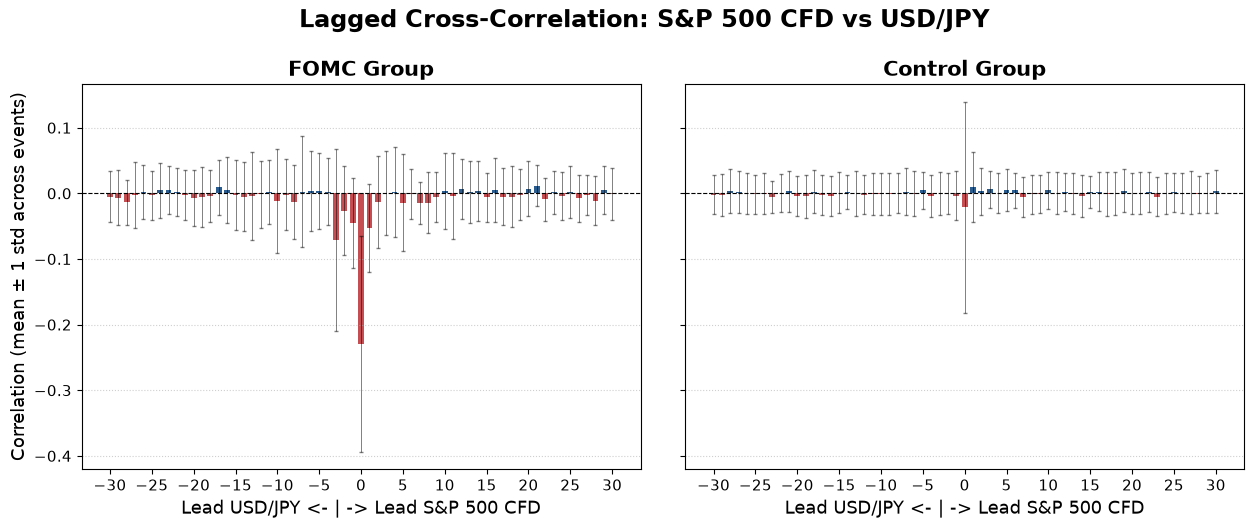

In [8]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_lagged_correlations(
    long_table_fomc, ax=ax1, title="FOMC Group", leader=LEADER, target=TARGET
)
plots.plot_lagged_correlations(
    long_table_control, ax=ax2, title="Control Group", leader=LEADER, target=TARGET
)
ax1.set_ylabel("Correlation (mean ± 1 std across events)", fontsize=13)
fig.suptitle(
    f"Lagged Cross-Correlation: S&P 500 CFD vs USD/JPY",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

## Model 2: Granger Causality

### Direction: Equities -> FX

In [9]:
# Generating GC summary data
long_table_fomc = models.summarize_across_realizations(
    fomc_data_returns_forward, models.compute_granger_causality, max_lag=30
)
long_table_control = models.summarize_across_realizations(
    control_group_data_returns_forward, models.compute_granger_causality, max_lag=30
)

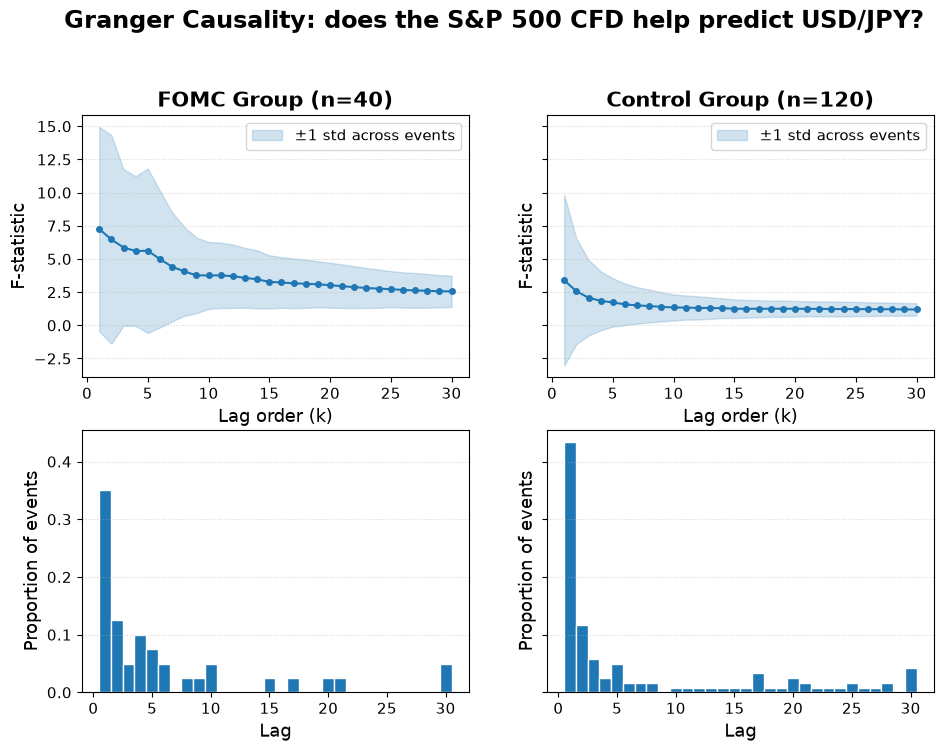

In [10]:
# Plotting output
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharey="row")
plots.plot_fstat_and_best_lag(
    long_table_fomc,
    axes=(axes[0, 0], axes[1, 0]),
    leader=LEADER,
    target=TARGET,
    group_label="FOMC Group",
)
plots.plot_fstat_and_best_lag(
    long_table_control,
    axes=(axes[0, 1], axes[1, 1]),
    leader=LEADER,
    target=TARGET,
    group_label="Control Group",
)
fig.suptitle(
    "Granger Causality: does the S&P 500 CFD help predict USD/JPY?",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)
plt.show()

### Direction: FX -> Equities

In [11]:
long_table_fomc_rev = models.summarize_across_realizations(
    fomc_data_returns_backward, models.compute_granger_causality, max_lag=30
)
long_table_control_rev = models.summarize_across_realizations(
    control_group_data_returns_backward, models.compute_granger_causality, max_lag=30
)

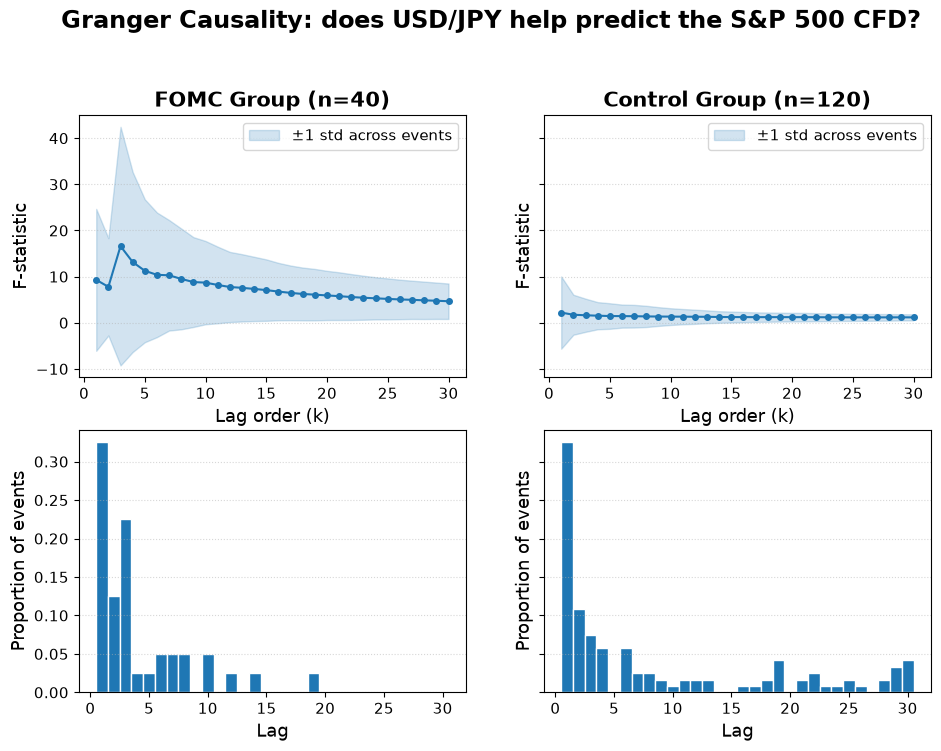

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharey="row")
plots.plot_fstat_and_best_lag(
    long_table_fomc_rev,
    axes=(axes[0, 0], axes[1, 0]),
    leader=TARGET,
    target=LEADER,
    group_label="FOMC Group",
)
plots.plot_fstat_and_best_lag(
    long_table_control_rev,
    axes=(axes[0, 1], axes[1, 1]),
    leader=TARGET,
    target=LEADER,
    group_label="Control Group",
)
fig.suptitle(
    "Granger Causality: does USD/JPY help predict the S&P 500 CFD?",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)
plt.show()

## Model 3: TDMI

### Direction: Equities -> FX

In [13]:
# Generating TDMI values
tdmi_fomc = models.compute_tdmi_pooled(fomc_data_returns_forward)
tdmi_control = models.compute_tdmi_pooled(control_group_data_returns_forward)

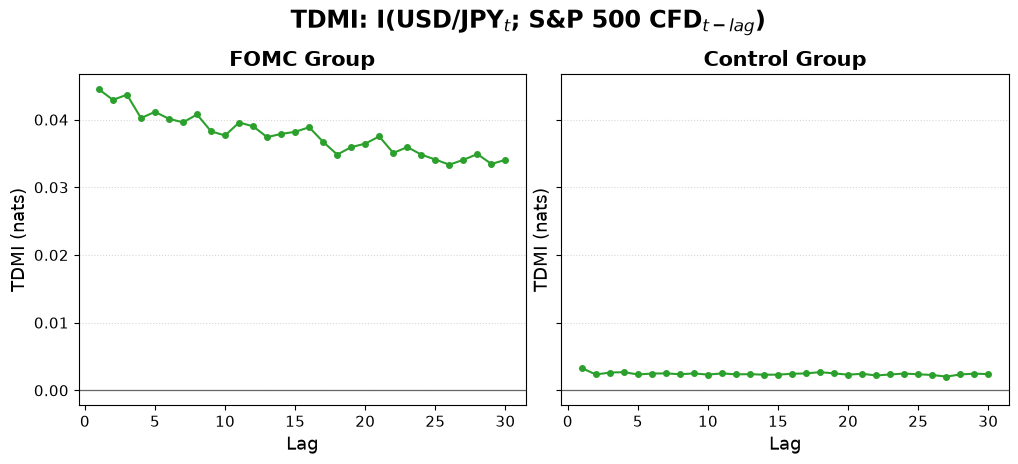

In [14]:
# Plotting them
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_tdmi(
    tdmi_fomc, ax=ax1, leader=LEADER, target=TARGET, group_label="FOMC Group"
)
plots.plot_tdmi(
    tdmi_control, ax=ax2, leader=LEADER, target=TARGET, group_label="Control Group"
)
ax1.set_ylabel("TDMI (nats)", fontsize=13)
fig.suptitle(
    f"TDMI: I({'USD/JPY'}$_t$; {'S&P 500 CFD'}$_{{t-lag}}$)",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

### Direction: FX -> Equities

In [15]:
tdmi_fomc_rev = models.compute_tdmi_pooled(fomc_data_returns_backward)
tdmi_control_rev = models.compute_tdmi_pooled(control_group_data_returns_backward)

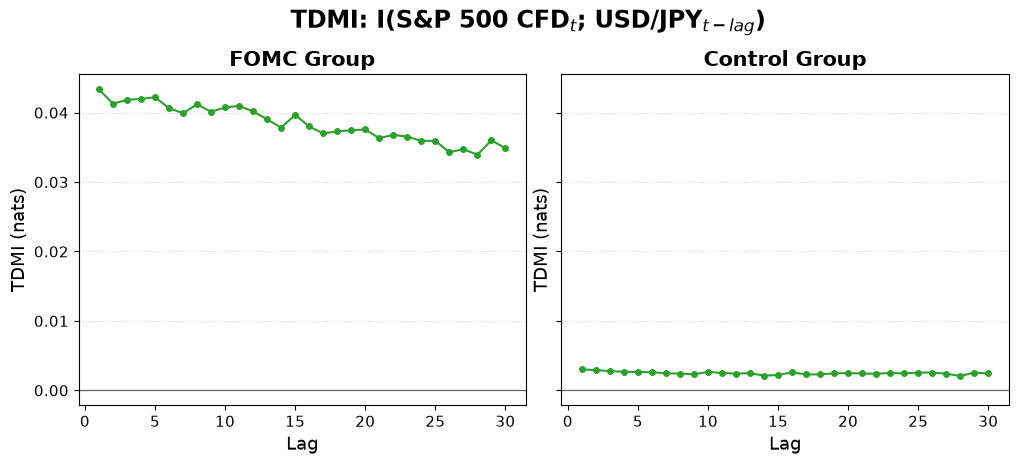

In [16]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_tdmi(
    tdmi_fomc_rev, ax=ax1, leader=TARGET, target=LEADER, group_label="FOMC Group"
)
plots.plot_tdmi(
    tdmi_control_rev, ax=ax2, leader=TARGET, target=LEADER, group_label="Control Group"
)
ax1.set_ylabel("TDMI (nats)", fontsize=13)
fig.suptitle(
    f"TDMI: I({'S&P 500 CFD'}$_t$; {'USD/JPY'}$_{{t-lag}}$)",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

## Transfer Entropy

### Direction: Equities -> FX

In [17]:
# Generating TE values
te_fomc = models.compute_te_pooled(fomc_data_returns_forward, max_lag=30)
te_control = models.compute_te_pooled(control_group_data_returns_forward, max_lag=30)

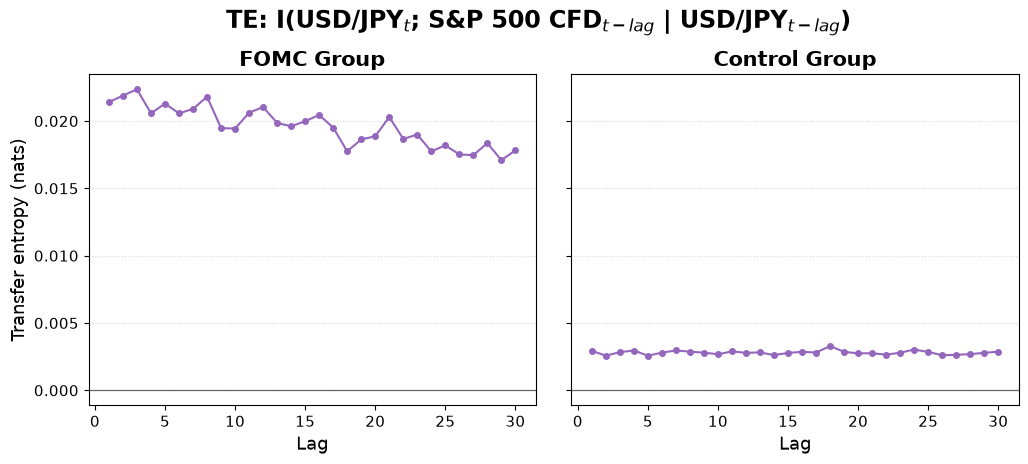

In [18]:
# Plotting them
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_transfer_entropy(
    te_fomc, ax=ax1, leader=LEADER, target=TARGET, group_label="FOMC Group"
)
plots.plot_transfer_entropy(
    te_control, ax=ax2, leader=LEADER, target=TARGET, group_label="Control Group"
)
ax2.set_ylabel("")
fig.suptitle(
    "TE: I(USD/JPY$_t$; S&P 500 CFD$_{t-lag}$ | USD/JPY$_{t-lag}$)",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

### Direction: FX -> Equities

In [19]:
te_fomc_rev = models.compute_te_pooled(fomc_data_returns_backward, max_lag=30)
te_control_rev = models.compute_te_pooled(
    control_group_data_returns_backward, max_lag=30
)

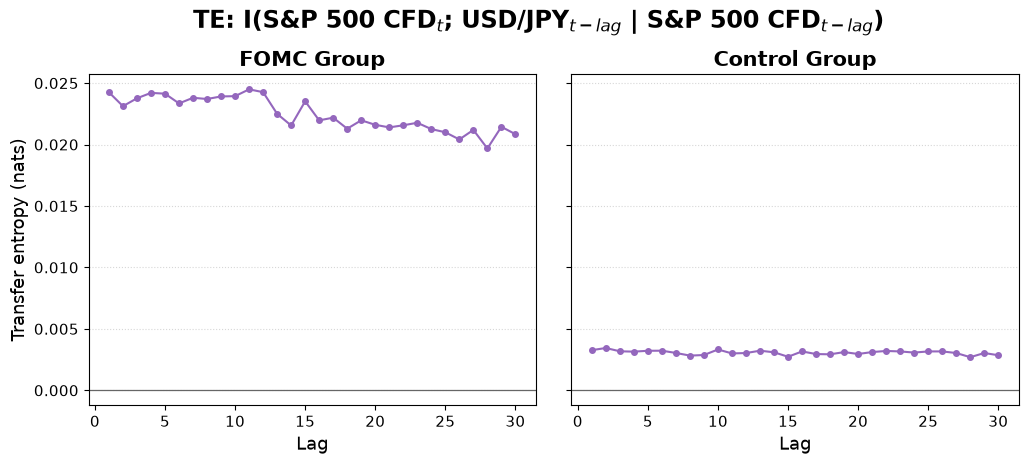

In [20]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_transfer_entropy(
    te_fomc_rev, ax=ax1, leader=TARGET, target=LEADER, group_label="FOMC Group"
)
plots.plot_transfer_entropy(
    te_control_rev, ax=ax2, leader=TARGET, target=LEADER, group_label="Control Group"
)
ax2.set_ylabel("")
fig.suptitle(
    "TE: I(S&P 500 CFD$_t$; USD/JPY$_{t-lag}$ | S&P 500 CFD$_{t-lag}$)",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

## Non-Linear Transfer Entropy

### Direction: Equities -> FX

In [21]:
# Generating TE_NL values
te_nl_fomc = models.compute_te_nl_pooled(fomc_data_returns_forward, max_lag=30)
te_nl_control = models.compute_te_nl_pooled(
    control_group_data_returns_forward, max_lag=30
)

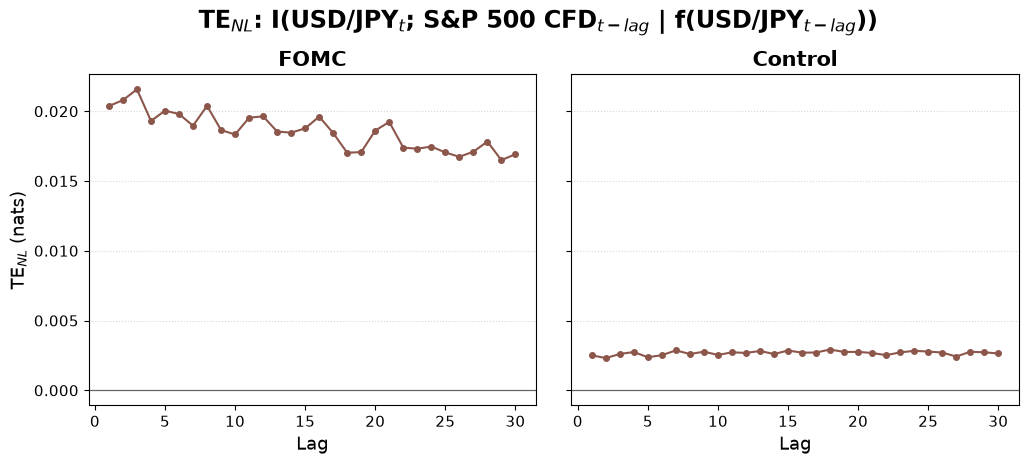

In [22]:
# Plotting them

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_nonlinear_transfer_entropy(
    te_nl_fomc, ax=ax1, leader=LEADER, target=TARGET, group_label="FOMC"
)
plots.plot_nonlinear_transfer_entropy(
    te_nl_control, ax=ax2, leader=LEADER, target=TARGET, group_label="Control"
)
ax2.set_ylabel("")
fig.suptitle(
    "TE$_{NL}$: I(USD/JPY$_t$; S&P 500 CFD$_{t-lag}$ | f(USD/JPY$_{t-lag}$))",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

### Direction: FX -> Equities

In [23]:
te_nl_fomc_rev = models.compute_te_nl_pooled(fomc_data_returns_backward, max_lag=30)
te_nl_control_rev = models.compute_te_nl_pooled(
    control_group_data_returns_backward, max_lag=30
)

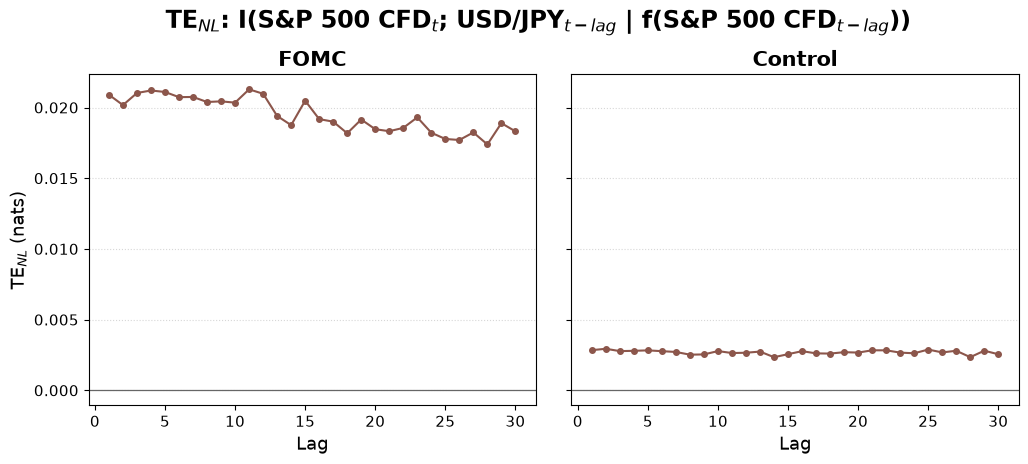

In [24]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.3), sharey=True, gridspec_kw={"wspace": 0.08}
)
plots.plot_nonlinear_transfer_entropy(
    te_nl_fomc_rev, ax=ax1, leader=TARGET, target=LEADER, group_label="FOMC"
)
plots.plot_nonlinear_transfer_entropy(
    te_nl_control_rev, ax=ax2, leader=TARGET, target=LEADER, group_label="Control"
)
ax2.set_ylabel("")
fig.suptitle(
    "TE$_{NL}$: I(S&P 500 CFD$_t$; USD/JPY$_{t-lag}$ | f(S&P 500 CFD$_{t-lag}$))",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)
plt.show()

## Application: Prediction

In [25]:
def compute_oos_prediction_gain(x, y, max_lag=10, train_frac=0.8, f=lambda z: z):
    """Computes OOS prediction gain by comparing a baseline AR model
    to an augmented one that also includes suggested leader's past"""
    x, y = pd.Series(x).reset_index(drop=True), pd.Series(y).reset_index(drop=True)
    x_f = f(x)
    rows = []
    for k in range(1, max_lag + 1):
        data = {"y_now": y}
        for lag in range(1, k + 1):
            data[f"y_lag{lag}"] = y.shift(lag)
            data[f"x_lag{lag}"] = x_f.shift(lag)
        aligned = pd.DataFrame(data).dropna().reset_index(drop=True)

        n = len(aligned)
        n_train = int(n * train_frac)
        train, test = aligned.iloc[:n_train], aligned.iloc[n_train:]
        if len(test) < 10:
            continue

        y_lag_cols = [f"y_lag{lag}" for lag in range(1, k + 1)]
        x_lag_cols = [f"x_lag{lag}" for lag in range(1, k + 1)]

        X_train_base = np.column_stack([np.ones(len(train)), train[y_lag_cols].values])
        X_test_base = np.column_stack([np.ones(len(test)), test[y_lag_cols].values])
        beta_base, _, _, _ = np.linalg.lstsq(
            X_train_base, train["y_now"].values, rcond=None
        )
        mse_base = np.mean((test["y_now"].values - X_test_base @ beta_base) ** 2)

        X_train_aug = np.column_stack(
            [np.ones(len(train)), train[y_lag_cols].values, train[x_lag_cols].values]
        )
        X_test_aug = np.column_stack(
            [np.ones(len(test)), test[y_lag_cols].values, test[x_lag_cols].values]
        )
        beta_aug, _, _, _ = np.linalg.lstsq(
            X_train_aug, train["y_now"].values, rcond=None
        )
        mse_aug = np.mean((test["y_now"].values - X_test_aug @ beta_aug) ** 2)

        rows.append(
            {
                "lag": k,
                "mse_baseline": mse_base,
                "mse_augmented": mse_aug,
                "pct_improvement": 100 * (mse_base - mse_aug) / mse_base,
            }
        )
    return pd.DataFrame(rows)


def summarize_oos_gain(pairs, max_lag=10, train_frac=0.8, f=lambda z: z):
    tables = []
    for i, (x, y) in enumerate(pairs):
        table = compute_oos_prediction_gain(
            x, y, max_lag=max_lag, train_frac=train_frac, f=f
        )
        table["realization"] = i
        tables.append(table)
    return pd.concat(tables, ignore_index=True)

In [26]:
def _asset_label(asset):
    return "S&P 500 CFD" if asset == "E_SandP-500" else asset


def plot_oos_gain(
    long_table,
    ax=None,
    leader="X",
    target="Y",
    group_label=None,
    title_fontsize=15,
    label_fontsize=13,
    tick_fontsize=11,
):
    """Plots % reduction in out-of-sample MSE from adding leader's lags when
    predicting target"""
    leader_label = _asset_label(leader)
    target_label = _asset_label(target)
    summary = (
        long_table.groupby("lag")["pct_improvement"].agg(["mean", "std"]).reset_index()
    )

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.3))

    ax.plot(summary["lag"], summary["mean"], marker="o", markersize=4, color="tab:blue")
    ax.fill_between(
        summary["lag"],
        summary["mean"] - summary["std"],
        summary["mean"] + summary["std"],
        color="tab:blue",
        alpha=0.15,
    )
    ax.axhline(0, color="#666666", linewidth=0.9)
    ax.set_xlabel("Lag order (k)", fontsize=label_fontsize)
    ax.set_ylabel("% reduction in OOS MSE", fontsize=label_fontsize)

    if group_label:
        ax.set_title(group_label, fontsize=title_fontsize, fontweight="bold")
    else:
        ax.set_title(
            f"Does {leader_label}'s past improve out-of-sample prediction of {target_label}?",
            fontsize=title_fontsize,
            fontweight="bold",
        )
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

    if standalone:
        plt.tight_layout()
        plt.show()
    return ax

In [27]:
oos_fomc_fwd = summarize_oos_gain(fomc_data_returns_forward, max_lag=10)
oos_control_fwd = summarize_oos_gain(control_group_data_returns_forward, max_lag=10)
oos_fomc_rev = summarize_oos_gain(fomc_data_returns_backward, max_lag=10)
oos_control_rev = summarize_oos_gain(control_group_data_returns_backward, max_lag=10)

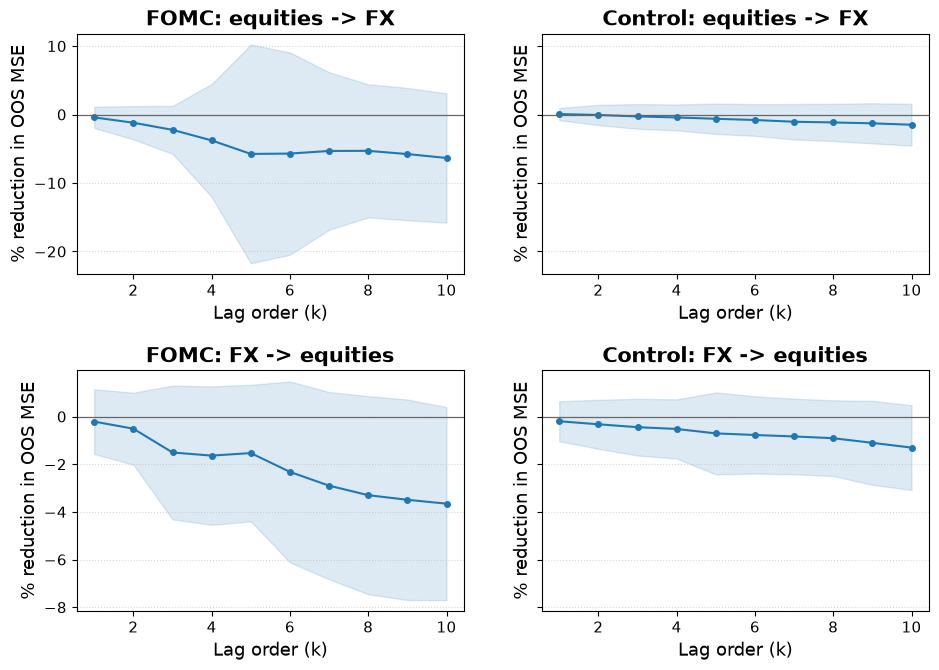

In [28]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 7.5), sharey="row", gridspec_kw={"hspace": 0.4}
)
plot_oos_gain(
    oos_fomc_fwd,
    ax=axes[0, 0],
    leader=LEADER,
    target=TARGET,
    group_label="FOMC: equities -> FX",
)
plot_oos_gain(
    oos_control_fwd,
    ax=axes[0, 1],
    leader=LEADER,
    target=TARGET,
    group_label="Control: equities -> FX",
)
plot_oos_gain(
    oos_fomc_rev,
    ax=axes[1, 0],
    leader=TARGET,
    target=LEADER,
    group_label="FOMC: FX -> equities",
)
plot_oos_gain(
    oos_control_rev,
    ax=axes[1, 1],
    leader=TARGET,
    target=LEADER,
    group_label="Control: FX -> equities",
)
plt.show()

## Analysis: Speed of reaction/renormalization

In [29]:
def compute_t50(event_df, col, event_timestamp):
    """Computes the number of seconds after event_timestamp at which cumulative
    squared 1-second log returns first reach 50% of their eventual post-announcement total
    (a proxy for realized volatility). Returns NaN if the post-announcement window
    shows no variation at all (e.g. every tick is stale)"""
    post = event_df.loc[event_df.index >= event_timestamp, col]
    returns = np.log(post).diff().dropna()
    sq = returns.values**2
    total = sq.sum()
    if total == 0 or np.isnan(total):
        return np.nan
    cum_frac = np.cumsum(sq) / total
    idx = np.argmax(cum_frac >= 0.5)
    return idx  # seconds since announcement, given 1-second sampling


def summarize_t50(data_dict, leader_col, target_col):
    """Runs compute_t50 for both leader and target on every event in
    data_dict, returns one row per event with both T50s and the gap
    between them (positive gap = target took longer than leader)"""
    rows = []
    for event_ts, event_df in data_dict.items():
        t50_leader = compute_t50(event_df, leader_col, event_ts)
        t50_target = compute_t50(event_df, target_col, event_ts)
        rows.append(
            {
                "event": event_ts,
                "t50_leader": t50_leader,
                "t50_target": t50_target,
                "gap_target_minus_leader": t50_target - t50_leader,
            }
        )
    return pd.DataFrame(rows)


def plot_t50_comparison(
    t50_table,
    ax=None,
    leader="X",
    target="Y",
    group_label=None,
    title_fontsize=15,
    label_fontsize=13,
    tick_fontsize=11,
):
    """Boxplot comparing each asset's T50 across events."""
    leader_label = _asset_label(leader)
    target_label = _asset_label(target)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4.3))

    data = [t50_table["t50_leader"].dropna(), t50_table["t50_target"].dropna()]
    ax.boxplot(data, tick_labels=[leader_label, target_label], showfliers=False)
    ax.set_ylabel("T50 (seconds since announcement)", fontsize=label_fontsize)

    if group_label:
        ax.set_title(group_label, fontsize=title_fontsize, fontweight="bold")
    else:
        ax.set_title(
            f"Speed of reaction: {leader_label} vs {target_label}",
            fontsize=title_fontsize,
            fontweight="bold",
        )
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

    if standalone:
        plt.tight_layout()
        plt.show()
    return ax

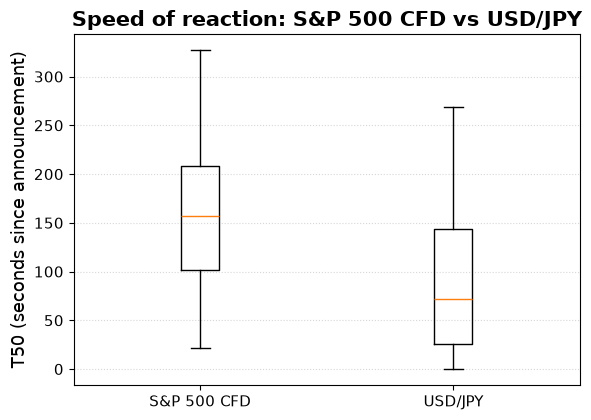

       t50_leader  t50_target  gap_target_minus_leader
count   40.000000    40.00000                40.000000
mean   157.525000    83.50000               -74.025000
std     87.497982    67.07707                88.600077
min     22.000000     0.00000              -327.000000
25%    101.750000    25.25000              -120.500000
50%    156.500000    71.50000               -69.000000
75%    208.000000   143.50000                -8.750000
max    439.000000   269.00000               174.000000


In [30]:
t50_fomc = summarize_t50(fomc_data, LEADER, TARGET)
plot_t50_comparison(t50_fomc, leader=LEADER, target=TARGET)
plt.show()

print(t50_fomc[["t50_leader", "t50_target", "gap_target_minus_leader"]].describe())